<a href="https://colab.research.google.com/github/rileyrichmond18/is_4487_classresources/blob/main/assignment_04_RichmondRiley.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IS4487 Week 4 - Assignment

### Outline

Our Goals with this Project:

1. Import and review the data
2. Perform EDA and Clean Data

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_04_data_understanding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Business Case: AdviseInvest
You work on a small team of data analysts at AdviseInvest, a venture-backed startup. The Director of Sales at AdviseInvest has approached your team asking for help solving a staffing problem.

### The Company
The company's mission is to provide tools and support to help ordinary people gain control of their personal finances. The company leverages technology to provide affordable financial advice to a national client base.

Customers who reach AdviseInvest's website go through five steps:

- Open an account.
- Complete a customer profile form with basic information about their background and finances.
- Schedule a free phone conversation with a sales representative during a 1-hour window of time.
- Attend the free phone conversation.
- Buy a financial plan.
- There are three types of financial plans: Beginner, Intermediate, and Advanced. Each is sold at a different price, and there are varying degrees of personalization. After a customer purchases a financial plan, the customer is assigned a financial planner who helps determine the customer's goals and advises the customer on spending decisions.

### The Problem
Some customers are lost at each stage of the process. Steps 3 and 4 are particularly challenging because approximately 50% of those who schedule a phone conversation fail to pick up the call. This leads to inefficiencies from a staffing perspective.

AdviseInvest has 4 sales reps on staff during each particular 1-hour window. Each of the 4 reps is assigned 2 prospective customers per hour, which means that the company schedules a total of 8 phone calls per hour. The calls are outgoing: sales reps call customers who scheduled a phone conversation during that hour window.

Unfortunately, as noted above, many of the customers who scheduled a call do not answer. As a consequence, sales reps are often left underutilized. Moreover, they are underutilized unevenly. For example, it is possible that one sales rep will not do any sales calls during that hour, whereas another will be busy the entire hour with two calls. Sales reps have nothing to do when customers do not answer the scheduled phone call.

### AdviseInvest Data Dictionary

| Variable | Description | Type | Code |
|:---|:---|:---|:---|
| Answered | Customer response | Binary | 0: customer did not answer scheduled call; 1: customer answered scheduled call |
| Income | Customer income in US dollars | Numeric | |
| Female | Customer gender | Binary | 0: female; 1: male |
| Age | Age in years | Numeric | |
| Job | Nature of job | Categorical | 0 : unemployed; 1 : entry level position; 2 : midlevel position; 3 : management/ self-employed/ highly qualified employee/ officer |
| Num_dependents | Number of people for whom the customer provides maintenance | Numeric | |
| Rent | Customer rents | Binary | 0: no; 1: yes |
| Own_res | Customer owns residence | Binary | 0: no; 1: yes |
| New_car | Recent new car purchase | Binary | New car purchase in the last 3 months: 0: no, 1: yes |
| Chk_acct | Checking account status | Categorical | 0 : no checking account; 1: checking < 200 USD; 2 : 200 < checking < 2000 USD; 3: 2000 < checking < 35000 USD; 4: >= 3500 USD |
| Sav_acct | Average balance in savings account | Categorical | 0 : no savings account; 1 : 100 <= savings < 500 USD; 2 : 500 <= savings < 2000 USD; 3 : 2000 < savings < 35000 USD; 4: >= 3500 USD |
| Num_accts | Number of accounts owned by customer | Numeric | |
| Mobile | Mobile phone | Binary | 0: customer provided non‐mobile phone for follow‐up call; 1: customer provided mobile phone for follow‐up call |
| Product | Type of product purchased after conversation with sales rep | Categorical | 0: customer did not answer call; 1: customer answered but did not purchase a product; 2: customer answered and purchased Beginner plan; 3: customer answered and purchased Intermediate plan; 4: customer answered and purchased Advanced plan |


### Load Libraries

Import the libraries you will need, such as:
- Pandas
- Sklearn
- Matplotlib


In [2]:
#Import libraries 🔧

import pandas as pd
import sklearn
import matplotlib.pyplot as plt


## Step 1: Initial Data Understanding

### Do the following:
 - Import data from the AdviseInvest historical dataset into a dataframe (in GitHub go to Assignments > DataSets)
 - Describe or profile the dataframe
 - Look for any outliers, missing values, or duplicates

In [3]:
#Import the data 🔧

url = "https://raw.githubusercontent.com/rileyrichmond18/is_4487_classresources/refs/heads/main/DataSets/adviseinvest_historical_data.csv"

df = pd.read_csv(url)


In [4]:
#View the datatypes 🔧

head = df.head()
print(head)

print("-----------------------------------------------")

info = df.info()
print(info)

print("-----------------------------------------------")

nullCheck = df.isnull().sum()
print(nullCheck)


   answered  income female  age  job  num_dependents  rent  own_res  new_car  \
0         1   13520      0   23    0               1     1        0      0.0   
1         0   14780      0   22    2               1     0        1      0.0   
2         1   37570      0   62    2               1     0        0      1.0   
3         0   12450      0   33    2               1     0        1      0.0   
4         0   12400      0   48    1               2     0        0      1.0   

   chk_acct  sav_acct  num_accts  mobile  product  
0         0         2          0       1        2  
1         3         0          3       0        0  
2         3         0          4       0        4  
3         1         0          2       0        0  
4         2         1          4       0        0  
-----------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29504 entries, 0 to 29503
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  

In [5]:
#Describe the data 🔧

describe = df.describe()
print(describe)

print("--------------------------------------")

dupeCheck = df.duplicated().sum
print(dupeCheck)

           answered         income           age           job  \
count  29504.000000   29504.000000  29504.000000  29504.000000   
mean       0.546638   33766.893303     34.773454      1.915401   
std        0.497829   29379.202710     11.369865      0.658183   
min        0.000000  -65600.000000     19.000000      0.000000   
25%        0.000000   13550.000000     26.000000      2.000000   
50%        1.000000   23310.000000     32.000000      2.000000   
75%        1.000000   41690.000000     40.000000      2.000000   
max        1.000000  159450.000000    132.000000      3.000000   

       num_dependents          rent       own_res       new_car      chk_acct  \
count    29504.000000  29504.000000  29504.000000  29502.000000  29504.000000   
mean         1.140998      0.210412      0.681128      0.240797      1.468547   
std          0.348025      0.407608      0.466047      0.427575      1.234727   
min          1.000000      0.000000      0.000000      0.000000      0.000000   


# Step 2: Exploratory Data Analysis (EDA)
### Do the following:
- Explore the relationships between the target and independent variables
- Create at least five charts to show the relationships, using different chart types that are approriate to the analysis
- Ensure that all charts are clearly labeled and formatted

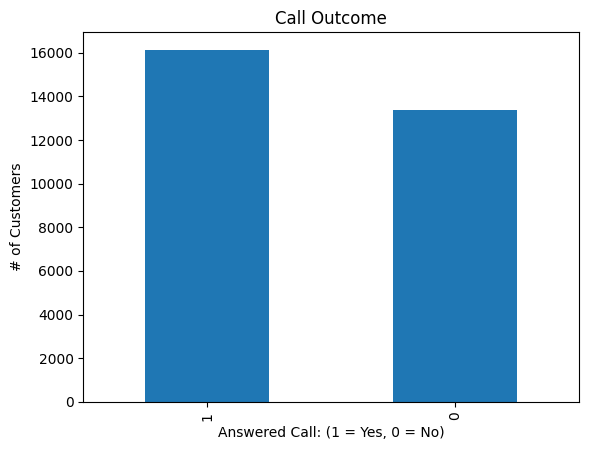

In [6]:
# Chart 1 🔧

df['answered'].value_counts().plot(kind='bar')
plt.title("Call Outcome")
plt.xlabel("Answered Call: (1 = Yes, 0 = No)")
plt.ylabel("# of Customers")
plt.show()


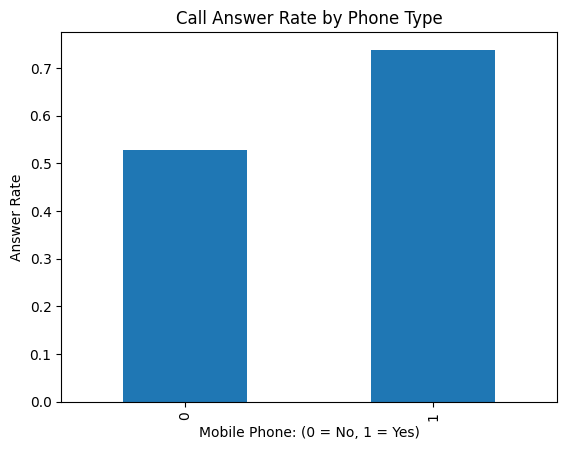

In [14]:
# Chart 2 🔧

df.groupby('mobile')['answered'].mean().plot(kind='bar')
plt.title("Call Answer Rate by Phone Type")
plt.xlabel("Mobile Phone: (0 = No, 1 = Yes)")
plt.ylabel("Answer Rate")
plt.show()


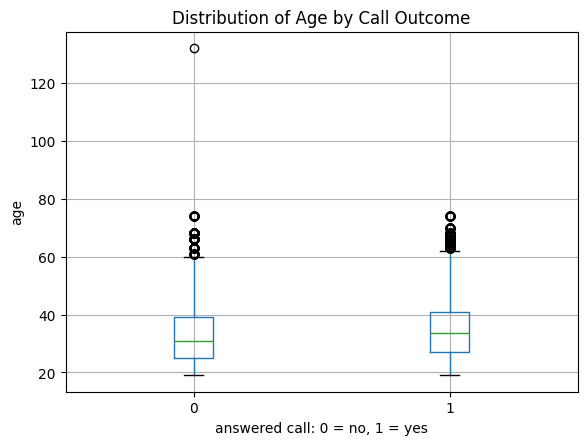

In [8]:
# Chart 3 🔧

df.boxplot(column='age', by='answered')
plt.title("Distribution of Age by Call Outcome")
plt.suptitle("")
plt.xlabel("answered call: 0 = no, 1 = yes")
plt.ylabel("age")
plt.show()


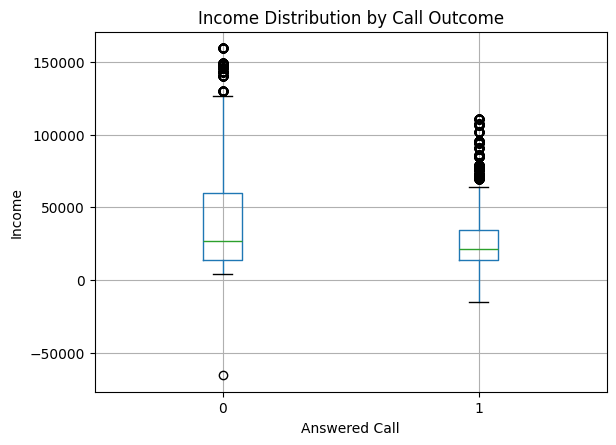

In [9]:
# Chart 4 🔧

df.boxplot(column='income', by='answered')
plt.title("Income Distribution by Call Outcome")
plt.suptitle("")
plt.xlabel("Answered Call")
plt.ylabel("Income")
plt.show()


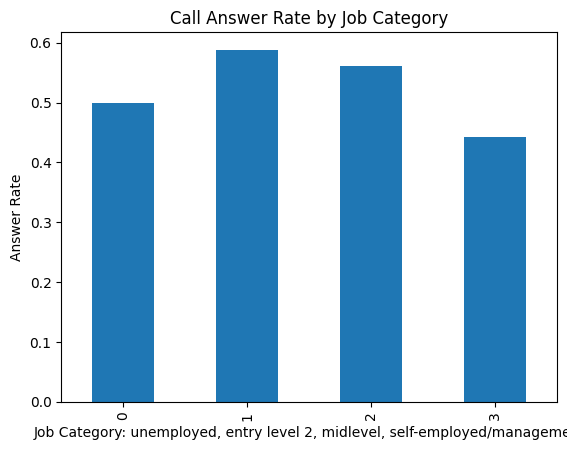

In [13]:
# Chart 5 🔧

df.groupby('job')['answered'].mean().plot(kind='bar')
plt.title("Call Answer Rate by Job Category")
plt.xlabel("Job Category: unemployed, entry level 2, midlevel, self-employed/management")
plt.ylabel("Answer Rate")
plt.show()


# Step 3: Summarize Your Findings
Question 3.1: Are all of the variables useful and applicable to the business need?  (you should reference the target variable and whether other variables have are likely to be correlated with the target)

### ✍️ Your Response: 🔧
3.1. The business objective is to increase sales rep utilization by increasing the customer answer rate, which is the target variable. In terms of the dataset, the target variable is 'answered'. The objective then is to evaluate if the other variables have any correlation or influence with the target variable, which will give us a better insight to optimize the answer rate. Some variables appear to be more correlated with the target, while others are less so. The variables that are most correlated with the target will prove to be the most useful for data anaylsis and optimization, and other variables that depend on the outcome of the call like 'product' should not be incorporated with the analysis.

Question 3.2: In what ways could the dataset be improved?  Are there any data quality issues or data types that should be fixed?

### ✍️ Your Response: 🔧
3.2. The dataset has minimal null values, however, removing outliers would make the data more standardized for training an algorithm for optimizing the answer rate. Also, having a standardized naming system like camel case for variables would be better for neatness, coding purposes, and interpretability. For example, the variable "female" should be called gender, 0 = male, 1 = female. The time of day variable should also be accompanied by a time zone variable to provide context for where callers are when they get called.

## Submission Instructions

✅ **Before submitting:**
- Make sure all code cells are run and outputs are visible  
- All markdown questions are answered thoughtfully  
- Submit the assignment as an **HTML file** on Canvas

In [15]:
!jupyter nbconvert --to html "assignment_04_RichmondRiley.ipynb"

[NbConvertApp] Converting notebook assignment_04_RichmondRiley.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 5 image(s).
[NbConvertApp] Writing 432155 bytes to assignment_04_RichmondRiley.html
